In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from nca.model import *
from nca.rollout import *
from nca.viz import *
from nca.stats import *

import torch
import numpy as np
import imageio
from IPython.display import Image, display
from IPython.display import Video

In [3]:
device = torch.device("cpu")
model = NCA()
state = torch.load("../../snapshots/froggy_model_noregen.pth", map_location=device)
model.load_state_dict(state)
model.eval()  # VERY IMPORTANT

NCA(
  (net): Sequential(
    (0): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
  )
)

In [8]:
x0 = seed(1)  # initial seed, shape [1, C, H, W]
with torch.no_grad():
    states = rollout(
        model,
        x0,
        steps=100,
        ablate_channel=None,
        width_cut=None,
        killEye=150,
        prune=True,
        realEyeReplace=None,
        realEyeCapture=None,
        fakeEyeReplace=None,
        inhibit=None,
        injectionChannel=None,
        injectionTime=-1,
        injectionConcoction=False
    )
# states: (T, C, H, W)

In [9]:
cell_states = get_states_by_part(states)
stats = compute_mean_var_by_part(cell_states)

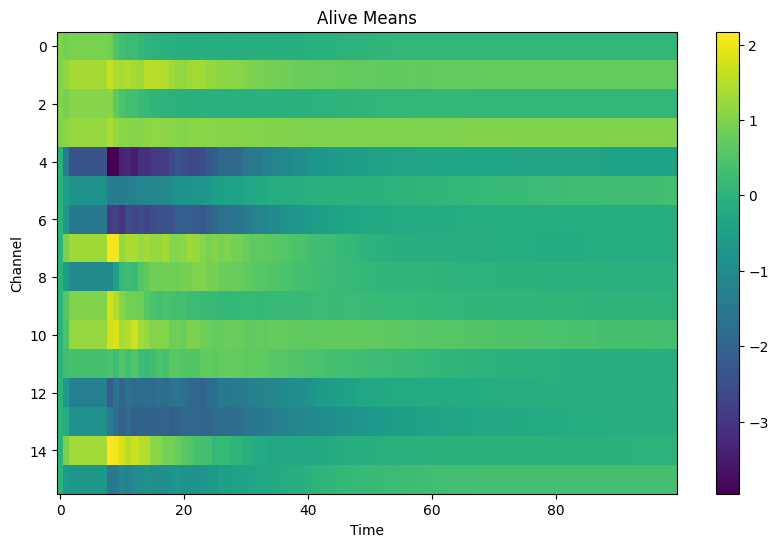

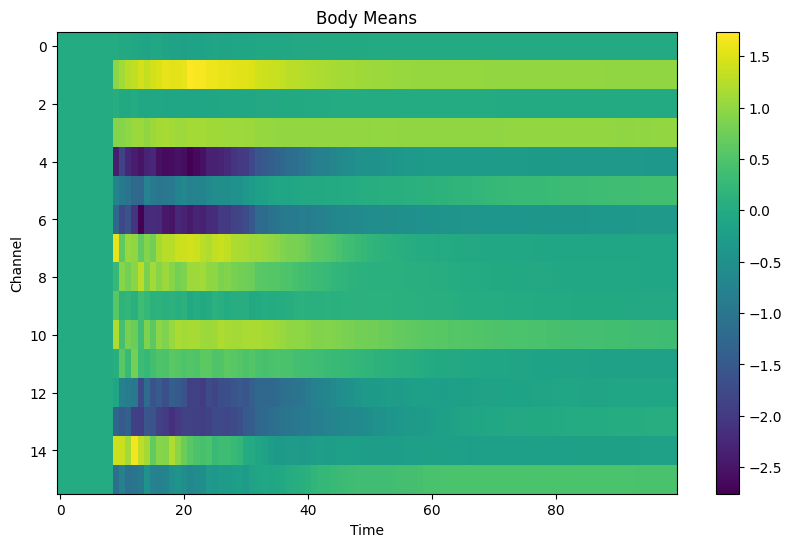

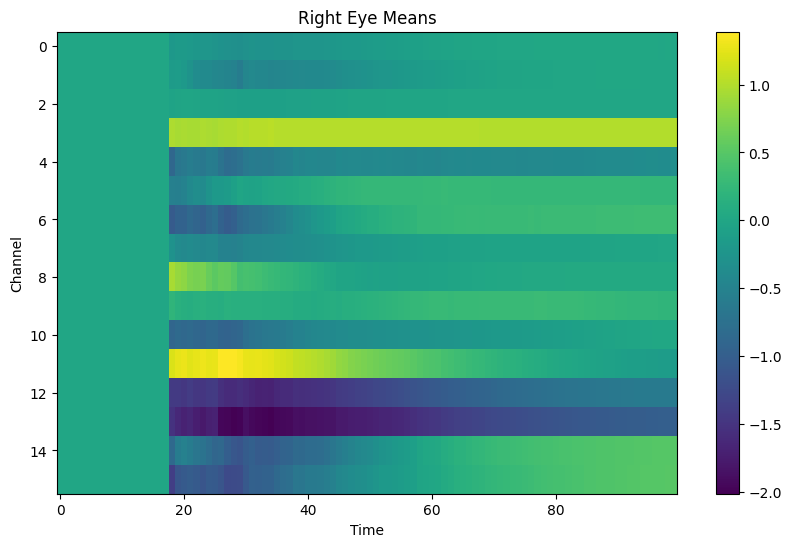

In [10]:
plot_means_heat(stats)